# Week 6 补充：随机森林复杂度实验

目标：只改变 `min_samples_leaf`，观察叶子节点最小样本数如何影响随机森林的训练表现、交叉验证平均分和波动。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 实验

`min_samples_leaf=1` 允许叶子节点只包含一个样本，树更细、更容易记住训练数据。数值增大后，每个叶子必须包含更多样本，树会更保守。测试集在本实验中不使用。

In [3]:
leaf_sizes = [1, 2, 5, 10, 20]
rows = []

for leaf_size in leaf_sizes:
    model = RandomForestClassifier(
        n_estimators=300,
        max_features='sqrt',
        min_samples_leaf=leaf_size,
        random_state=42,
        n_jobs=-1,
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        return_train_score=True,
        n_jobs=-1,
    )

    rows.append({
        'min_samples_leaf': leaf_size,
        'train_mean': scores['train_score'].mean(),
        'validation_mean': scores['test_score'].mean(),
        'validation_std': scores['test_score'].std(),
    })

leaf_results = pd.DataFrame(rows)
display(leaf_results.round(3))

,min_samples_leaf,train_mean,validation_mean,validation_std
0,1,1.000,0.965,0.018
1,2,0.993,0.958,0.015
2,5,0.984,0.954,0.011
3,10,0.973,0.947,0.015
4,20,0.958,0.943,0.018


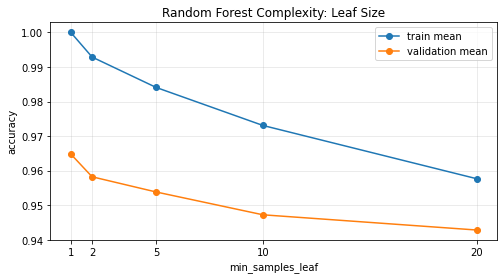

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(leaf_results['min_samples_leaf'], leaf_results['train_mean'], marker='o', label='train mean')
plt.plot(leaf_results['min_samples_leaf'], leaf_results['validation_mean'], marker='o', label='validation mean')
plt.xlabel('min_samples_leaf')
plt.ylabel('accuracy')
plt.title('Random Forest Complexity: Leaf Size')
plt.xticks(leaf_sizes)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 检查点

1. `min_samples_leaf` 变大后，为什么训练准确率通常会下降？
2. 选择参数时，为什么不能只选训练准确率最高的值？
3. 如果两个参数的交叉验证平均分接近，你还会比较什么？